# Task 1A: Exploratory Data Analysis

## Dataset Context

This notebook presents an exploratory data analysis of the **StudentLife-style mood and smartphone sensor dataset** collected from 27 mental health patients (AS14.01 through AS14.33). Participants self-reported their mood multiple times per day while their smartphones passively recorded sensor data including screen usage, app category durations, call and SMS activity, and physical activity levels.

The dataset is stored in **long format**: each row represents a single measurement of one variable for one patient at one timestamp. The goal of this EDA is to understand the structure, quality, and distributional properties of the data before building predictive models for mood in later tasks.

We address three sub-questions:
1. **Dataset statistics** -- records, attributes, value ranges, distributions, relationships, and missing values
2. **Feature visualisations** -- plots that reveal distributional shape, temporal patterns, and inter-variable relationships
3. **Interpretation and rationale** -- what these findings mean for downstream modelling decisions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (10, 5)})

# Load data
DATA_PATH = "../../Assignment 1 (Advanced)/data/dataset_mood_smartphone.csv"
df = pd.read_csv(DATA_PATH, index_col=0)
df["time"] = pd.to_datetime(df["time"])

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Shape: (376912, 4)
Columns: ['id', 'time', 'variable', 'value']


,id,time,variable,value
1,AS14.01,2014-02-26 13:00:00,mood,6.0
2,AS14.01,2014-02-26 15:00:00,mood,6.0
3,AS14.01,2014-02-26 18:00:00,mood,6.0
4,AS14.01,2014-02-26 21:00:00,mood,7.0
5,AS14.01,2014-02-27 09:00:00,mood,6.0
6,AS14.01,2014-02-27 12:00:00,mood,6.0
7,AS14.01,2014-02-27 15:00:00,mood,7.0
8,AS14.01,2014-03-21 09:00:00,mood,6.0
9,AS14.01,2014-03-21 11:00:00,mood,6.0
10,AS14.01,2014-03-21 15:00:00,mood,7.0


## 1. Dataset Overview

The dataset is in **long format** with four columns: `id` (patient identifier), `time` (timestamp), `variable` (the measured quantity), and `value` (the numeric measurement). This means each row is a single observation of a single variable for one patient at one point in time. There are 19 unique variables spanning three broad categories:

- **Self-report measures**: `mood` (1-10 integer scale), `circumplex.arousal` and `circumplex.valence` (both on a -2 to +2 continuous scale). These capture subjective emotional state using the Russell circumplex model.
- **Passive sensor measures**: `activity` (physical movement intensity, 0-1), `screen` (screen-on duration in seconds), `call` and `sms` (binary indicators for whether a call/SMS occurred).
- **App usage categories** (12 variables): `appCat.builtin`, `appCat.communication`, `appCat.entertainment`, `appCat.finance`, `appCat.game`, `appCat.office`, `appCat.other`, `appCat.social`, `appCat.travel`, `appCat.unknown`, `appCat.utilities`, `appCat.weather`. Each records duration in seconds.

In [2]:
# Basic dataset statistics
print(f"Total records:       {len(df):,}")
print(f"Unique patients:     {df['id'].nunique()}")
print(f"Unique variables:    {df['variable'].nunique()}")
print(f"Date range:          {df['time'].min().date()} to {df['time'].max().date()}")
print(f"Duration:            {(df['time'].max() - df['time'].min()).days} days")
print()

# Records per variable
print("Records per variable:")
print(df["variable"].value_counts().to_string())

Total records:       376,912
Unique patients:     27
Unique variables:    19
Date range:          2014-02-17 to 2014-06-09
Duration:            111 days

Records per variable:
variable
screen                  96578
appCat.builtin          91288
appCat.communication    74276
appCat.entertainment    27125
activity                22965
appCat.social           19145
appCat.other             7650
circumplex.valence       5643
circumplex.arousal       5643
appCat.office            5642
mood                     5641
call                     5239
appCat.travel            2846
appCat.utilities         2487
sms                      1798
appCat.finance            939
appCat.unknown            939
appCat.game               813
appCat.weather            255


In [3]:
# Summary statistics per variable: count, mean, std, min, max, % missing values
# "Missing" here means: for a given patient-day, the variable has no observation at all
# First, let's compute per-variable descriptive statistics on the value column

var_stats = (
    df.groupby("variable")["value"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(3)
)

# Compute % of values that are NaN in the raw data
nan_pct = (
    df.groupby("variable")["value"]
    .apply(lambda x: x.isna().mean() * 100)
    .round(1)
    .rename("pct_nan")
)

var_stats = var_stats.join(nan_pct)
var_stats = var_stats.sort_values("count", ascending=False)
var_stats

,count,mean,std,min,max,pct_nan
variable,,,,,,
screen,96578,75.335,253.822,0.035,9867.007,0.0
appCat.builtin,91288,18.538,415.989,-82798.871,33960.246,0.0
appCat.communication,74276,43.344,128.913,0.006,9830.777,0.0
appCat.entertainment,27125,37.576,262.960,-0.011,32148.677,0.0
activity,22965,0.116,0.187,0.000,1.000,0.0
appCat.social,19145,72.402,261.552,0.094,30000.906,0.0
appCat.other,7650,25.811,112.781,0.014,3892.038,0.0
appCat.office,5642,22.579,449.601,0.003,32708.818,0.0
mood,5641,6.993,1.033,1.000,10.000,0.0


**Interpretation:** The table above reveals several important properties. The self-report variables (`mood`, `circumplex.arousal`, `circumplex.valence`) have relatively low record counts compared to passive sensors like `screen` and `appCat.*`, because they depend on participants actively responding to prompts. App category variables have vastly different record counts: `appCat.builtin` and `appCat.communication` are recorded frequently, while categories like `appCat.weather`, `appCat.game`, and `appCat.finance` are rare, reflecting that not all patients use those app types.

The `pct_nan` column shows the percentage of rows with a missing `value`. Some variables (especially circumplex measures) have non-trivial NaN rates even among recorded rows, which requires careful handling during feature engineering.

## 2. Missing Data Analysis

Missing data is a critical concern for this dataset. In long format, "missingness" has two dimensions: (1) explicit NaN values in recorded rows, and (2) the complete absence of a variable for a given patient-day. We examine both below.

First, we pivot the data to a daily patient-level wide format and then measure how often each variable is available. This gives us a practical view of what fraction of patient-days actually have usable data for each feature.

In [4]:
# Create a daily aggregated wide-format dataframe
df["date"] = df["time"].dt.date

daily = (
    df.dropna(subset=["value"])
    .groupby(["id", "date", "variable"])["value"]
    .mean()
    .reset_index()
    .pivot_table(index=["id", "date"], columns="variable", values="value")
)

print(f"Daily wide-format shape: {daily.shape}")
print(f"  = {daily.index.get_level_values('id').nunique()} patients x ~{daily.shape[0] // daily.index.get_level_values('id').nunique()} days/patient on average")
print()

# Percentage of missing values per variable in wide format
missing_pct = (daily.isna().mean() * 100).round(1).sort_values(ascending=False)
print("% missing (patient-days without any observation):")
print(missing_pct.to_string())

Daily wide-format shape: (1973, 19)
  = 27 patients x ~73 days/patient on average

% missing (patient-days without any observation):
variable
appCat.weather          94.3
appCat.game             90.2
appCat.finance          89.5
appCat.unknown          86.6
appCat.office           86.0
appCat.travel           78.3
appCat.utilities        78.1
sms                     62.8
appCat.entertainment    56.9
appCat.social           49.9
appCat.other            43.2
appCat.communication    40.0
activity                39.8
appCat.builtin          39.4
screen                  38.8
circumplex.valence      35.8
circumplex.arousal      35.7
mood                    35.7
call                    32.2


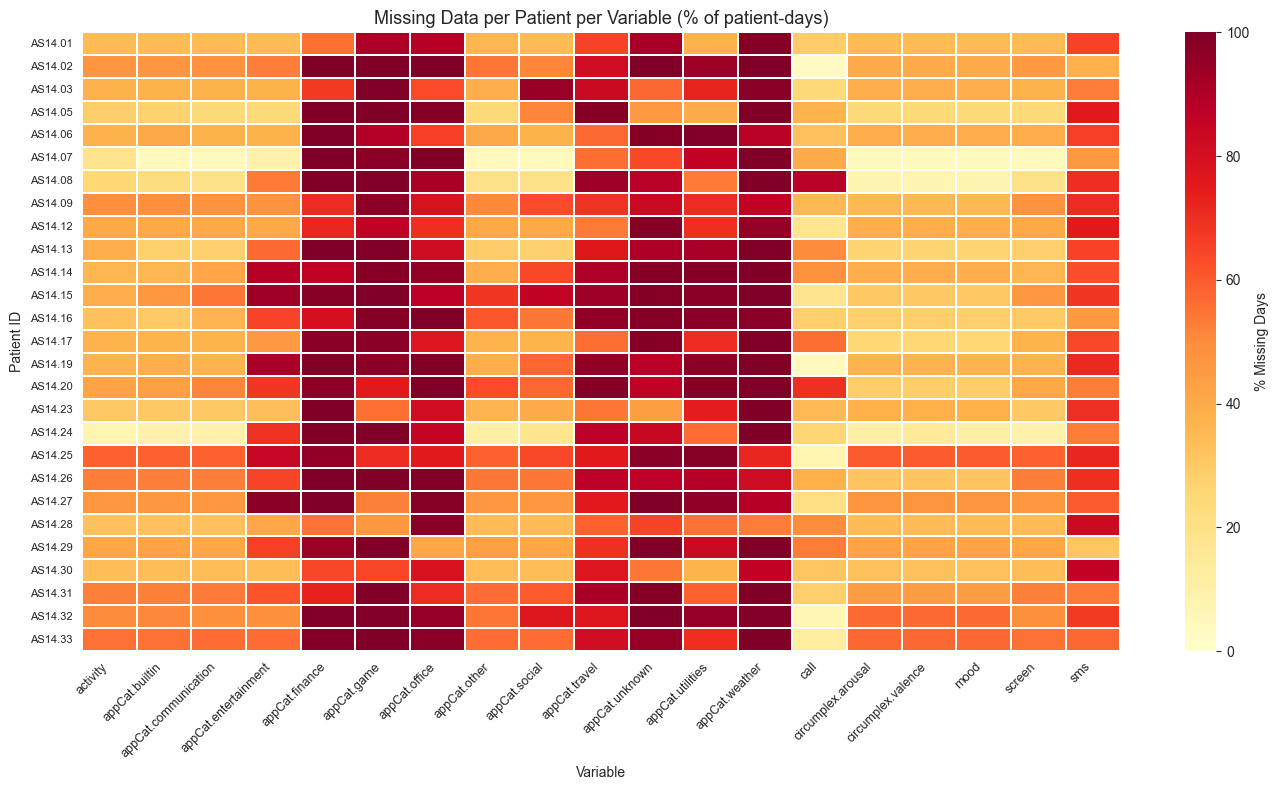

In [5]:
# Visualise missing data: heatmap of availability per variable per patient
missing_by_patient = daily.groupby(level="id").apply(lambda x: x.isna().mean() * 100)
missing_by_patient = missing_by_patient.droplevel(0) if missing_by_patient.index.nlevels > 1 else missing_by_patient

# Aggregate to patient level
patient_missing = daily.groupby(level="id").apply(lambda x: x.isna().mean() * 100)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    patient_missing,
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "% Missing Days"},
    ax=ax,
    linewidths=0.3,
)
ax.set_title("Missing Data per Patient per Variable (% of patient-days)", fontsize=13)
ax.set_xlabel("Variable")
ax.set_ylabel("Patient ID")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap clearly reveals a two-tier structure in data availability. Core variables like `mood`, `screen`, `activity`, `appCat.builtin`, `appCat.communication`, and `appCat.social` are available for the majority of patient-days. In contrast, niche app categories such as `appCat.weather`, `appCat.game`, `appCat.finance`, `appCat.unknown`, `appCat.office`, `appCat.travel`, and `appCat.utilities` are missing for over 80% of patient-days in many patients. This is not random missingness but rather structural: patients who do not use finance or gaming apps simply generate no data for those categories.

**Implication for modelling:** These sparse app categories cannot be used as continuous features without heavy imputation. A practical strategy is to either (a) drop them, (b) binarise them (used vs. not used on a given day), or (c) aggregate all minor categories into a single "other apps" feature. We will revisit this during feature engineering.

## 3. Distribution Plots

Understanding the marginal distributions of each variable is essential for choosing appropriate transformations, detecting outliers, and anticipating modelling challenges. Below we examine the key variables individually.

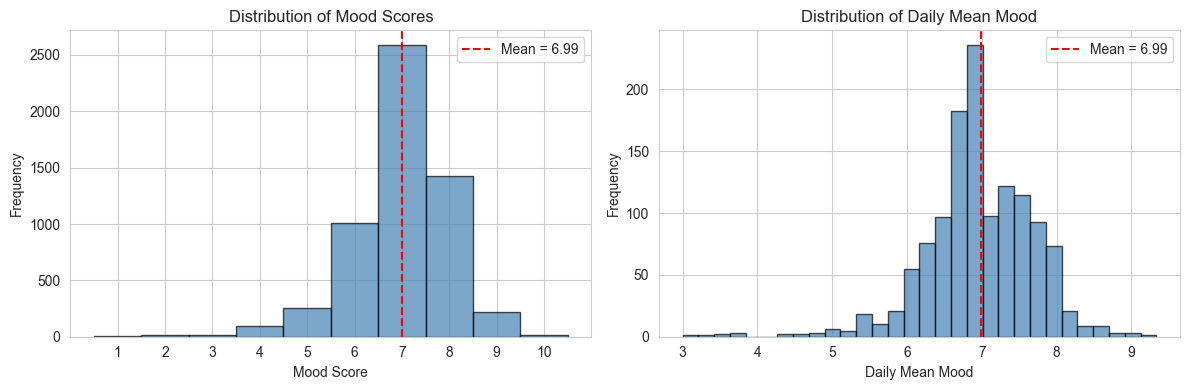

Mood: range [1, 10], mean=6.99, std=1.03
Daily mood: range [3.00, 9.33], mean=6.99, std=0.74


In [6]:
# 3a. Mood distribution
mood_vals = df.loc[df["variable"] == "mood", "value"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(mood_vals, bins=np.arange(0.5, 11.5, 1), edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_xlabel("Mood Score")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Mood Scores")
axes[0].set_xticks(range(1, 11))
axes[0].axvline(mood_vals.mean(), color="red", linestyle="--", label=f"Mean = {mood_vals.mean():.2f}")
axes[0].legend()

# Daily mean mood distribution
daily_mood = daily["mood"].dropna()
axes[1].hist(daily_mood, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].set_xlabel("Daily Mean Mood")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Daily Mean Mood")
axes[1].axvline(daily_mood.mean(), color="red", linestyle="--", label=f"Mean = {daily_mood.mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mood: range [{mood_vals.min():.0f}, {mood_vals.max():.0f}], mean={mood_vals.mean():.2f}, std={mood_vals.std():.2f}")
print(f"Daily mood: range [{daily_mood.min():.2f}, {daily_mood.max():.2f}], mean={daily_mood.mean():.2f}, std={daily_mood.std():.2f}")

**Mood distribution:** The mood scores are concentrated in a narrow band between 5 and 8, with the mode around 7. This is a well-known property of mood self-report data: most people report "slightly above neutral" most of the time. The daily mean mood is even more concentrated (roughly 6 to 8) because averaging across multiple reports per day smooths out variability. This narrow effective range makes mood prediction inherently challenging, since small improvements in RMSE correspond to meaningful gains.

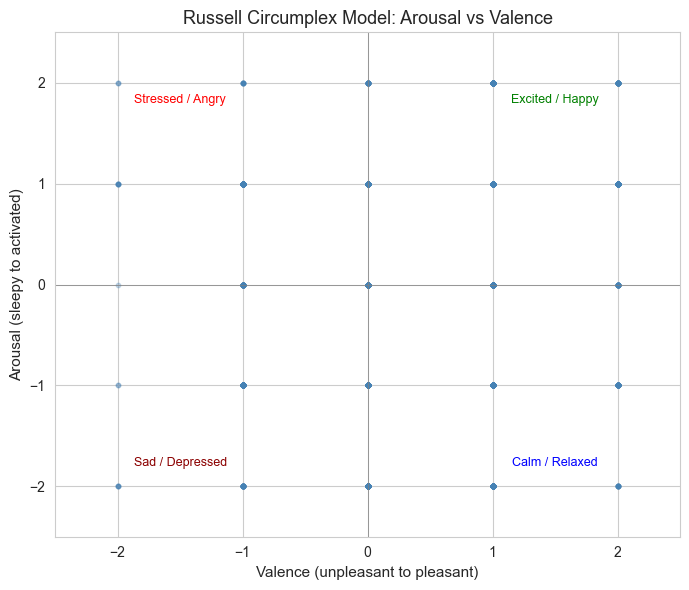

Circumplex observations (matched pairs): 5,506
Valence: mean=0.69, std=0.67
Arousal: mean=-0.11, std=1.05


In [7]:
# 3b. Circumplex arousal vs valence scatter
arousal = df.loc[df["variable"] == "circumplex.arousal", ["id", "time", "value"]].rename(columns={"value": "arousal"})
valence = df.loc[df["variable"] == "circumplex.valence", ["id", "time", "value"]].rename(columns={"value": "valence"})
circ = arousal.merge(valence, on=["id", "time"], how="inner").dropna()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(circ["valence"], circ["arousal"], alpha=0.15, s=10, color="steelblue")
ax.set_xlabel("Valence (unpleasant to pleasant)", fontsize=11)
ax.set_ylabel("Arousal (sleepy to activated)", fontsize=11)
ax.set_title("Russell Circumplex Model: Arousal vs Valence", fontsize=13)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)

# Quadrant labels
ax.text(1.5, 1.8, "Excited / Happy", ha="center", fontsize=9, color="green")
ax.text(-1.5, 1.8, "Stressed / Angry", ha="center", fontsize=9, color="red")
ax.text(-1.5, -1.8, "Sad / Depressed", ha="center", fontsize=9, color="darkred")
ax.text(1.5, -1.8, "Calm / Relaxed", ha="center", fontsize=9, color="blue")

plt.tight_layout()
plt.show()

print(f"Circumplex observations (matched pairs): {len(circ):,}")
print(f"Valence: mean={circ['valence'].mean():.2f}, std={circ['valence'].std():.2f}")
print(f"Arousal: mean={circ['arousal'].mean():.2f}, std={circ['arousal'].std():.2f}")

**Circumplex scatter:** The scatter plot shows that most observations cluster in the upper-right quadrant (positive valence, moderate arousal), consistent with the mood distribution skewing towards "generally OK." The discrete nature of the scale (-2, -1, 0, 1, 2) creates a visible grid pattern. Very few observations fall in the "sad/depressed" quadrant (low valence, low arousal), which means extreme negative mood states are underrepresented. This has implications for model performance at the tails: the model will have limited training signal for predicting bad days.

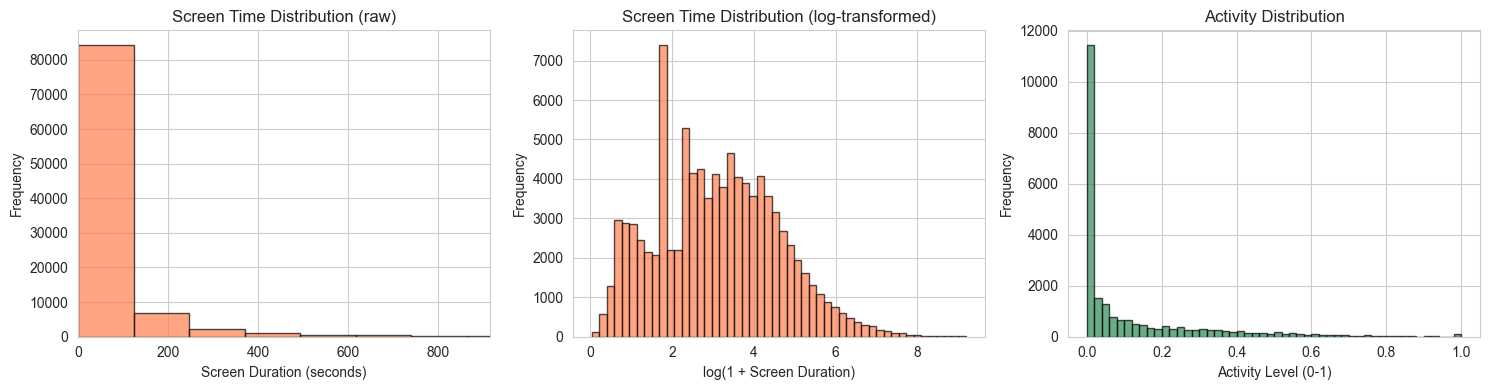

Screen: median=20s, mean=75s, max=9867s
  Skewness = 15.67 (heavily right-skewed)
Activity: mean=0.116, std=0.187


In [8]:
# 3c. Screen time and activity distributions
screen_vals = df.loc[df["variable"] == "screen", "value"].dropna()
activity_vals = df.loc[df["variable"] == "activity", "value"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Screen time (raw)
axes[0].hist(screen_vals, bins=80, edgecolor="black", alpha=0.7, color="coral")
axes[0].set_xlabel("Screen Duration (seconds)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Screen Time Distribution (raw)")
axes[0].set_xlim(0, screen_vals.quantile(0.99))

# Screen time (log-transformed)
log_screen = np.log1p(screen_vals)
axes[1].hist(log_screen, bins=50, edgecolor="black", alpha=0.7, color="coral")
axes[1].set_xlabel("log(1 + Screen Duration)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Screen Time Distribution (log-transformed)")

# Activity
axes[2].hist(activity_vals, bins=50, edgecolor="black", alpha=0.7, color="seagreen")
axes[2].set_xlabel("Activity Level (0-1)")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Activity Distribution")

plt.tight_layout()
plt.show()

print(f"Screen: median={screen_vals.median():.0f}s, mean={screen_vals.mean():.0f}s, max={screen_vals.max():.0f}s")
print(f"  Skewness = {screen_vals.skew():.2f} (heavily right-skewed)")
print(f"Activity: mean={activity_vals.mean():.3f}, std={activity_vals.std():.3f}")

**Screen time:** The raw screen duration is extremely right-skewed, with the vast majority of observations being short screen-on events and a long tail of extended sessions. The log-transformed version looks much closer to normal, confirming that a log-transform (or similar) should be applied before using screen time as a feature in linear models. Tree-based models can handle the skew natively, but normalising still helps with convergence.

**Activity:** Activity values span the full [0, 1] range with a roughly uniform-to-bimodal shape. The peaks near 0 and 1 suggest distinct states: sedentary vs. active. This variable is well-behaved and does not require transformation.

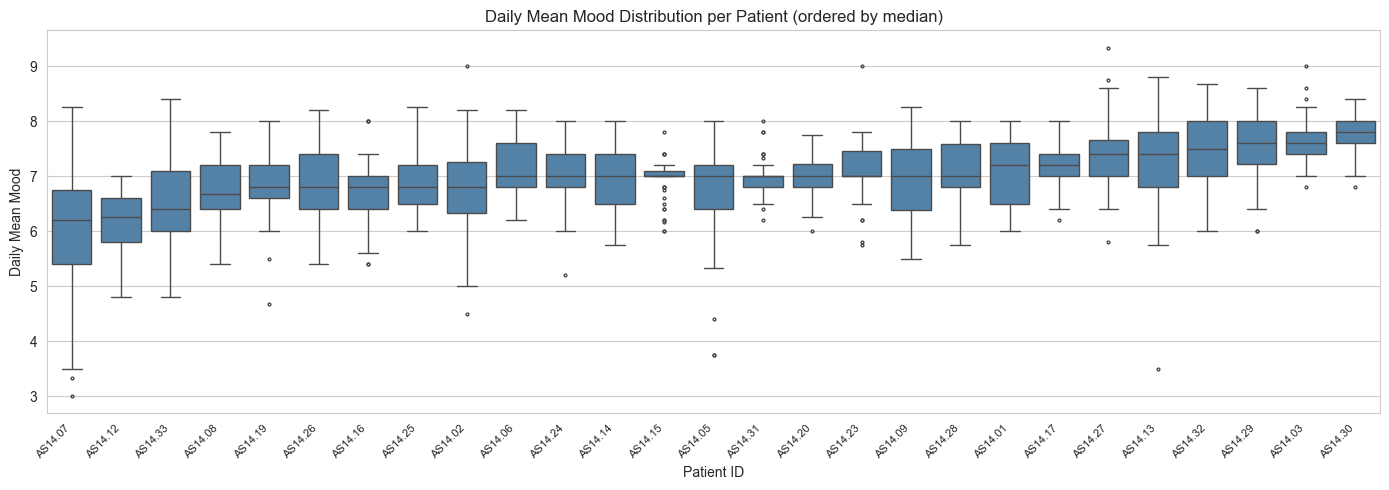

Patient mean mood: range [6.01, 7.78]
Patient mood std:  range [0.30, 1.17]
  Some patients are very stable (low std), others fluctuate considerably.


In [9]:
# 3d. Mood boxplots per patient
fig, ax = plt.subplots(figsize=(14, 5))
mood_per_patient = daily.reset_index()[["id", "mood"]].dropna()
patient_order = mood_per_patient.groupby("id")["mood"].median().sort_values().index

sns.boxplot(
    data=mood_per_patient,
    x="id",
    y="mood",
    order=patient_order,
    color="steelblue",
    fliersize=2,
    ax=ax,
)
ax.set_xlabel("Patient ID")
ax.set_ylabel("Daily Mean Mood")
ax.set_title("Daily Mean Mood Distribution per Patient (ordered by median)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

# Stats on inter-patient variability
patient_means = daily.groupby(level="id")["mood"].mean().dropna()
patient_stds = daily.groupby(level="id")["mood"].std().dropna()
print(f"Patient mean mood: range [{patient_means.min():.2f}, {patient_means.max():.2f}]")
print(f"Patient mood std:  range [{patient_stds.min():.2f}, {patient_stds.max():.2f}]")
print(f"  Some patients are very stable (low std), others fluctuate considerably.")

**Individual differences in mood:** The boxplots reveal substantial heterogeneity across patients. Some individuals (e.g., those on the left) have consistently low median mood with high variability, while others (right side) are stably positive. This between-patient variation is often larger than within-patient variation, meaning that a model which simply learns "patient X has mood ~7.5" would already capture much of the variance. This motivates using patient-specific features or a leave-patients-out evaluation strategy to ensure the model generalises to unseen individuals.

## 4. Temporal Patterns

Mood is a time-series signal collected repeatedly from the same individuals. Before modelling, we need to understand how mood evolves over time: is it stationary? Is there autocorrelation (i.e., does yesterday's mood predict today's)? Are there day-of-week effects? These questions determine whether temporal features (lags, rolling averages) should be included in the model.

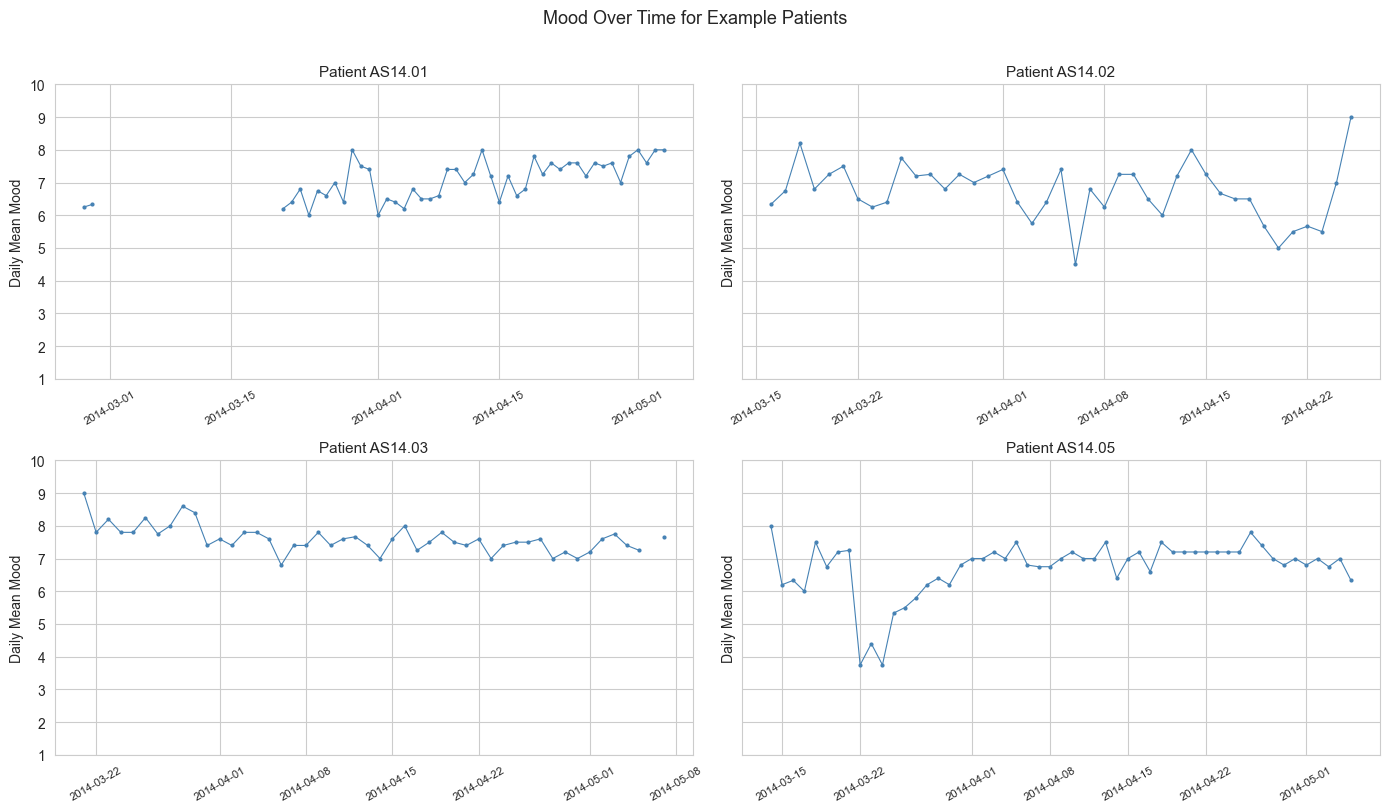

In [10]:
# 4a. Mood over time for selected patients
daily_reset = daily.reset_index()
daily_reset["date"] = pd.to_datetime(daily_reset["date"])

example_patients = daily_reset["id"].unique()[:4]  # first 4 patients

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=True)
for ax, pid in zip(axes.flat, example_patients):
    patient_data = daily_reset[daily_reset["id"] == pid].sort_values("date")
    ax.plot(patient_data["date"], patient_data["mood"], marker="o", markersize=2, linewidth=0.8, color="steelblue")
    ax.set_title(f"Patient {pid}", fontsize=11)
    ax.set_ylabel("Daily Mean Mood")
    ax.set_ylim(1, 10)
    ax.tick_params(axis="x", rotation=30, labelsize=8)

plt.suptitle("Mood Over Time for Example Patients", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

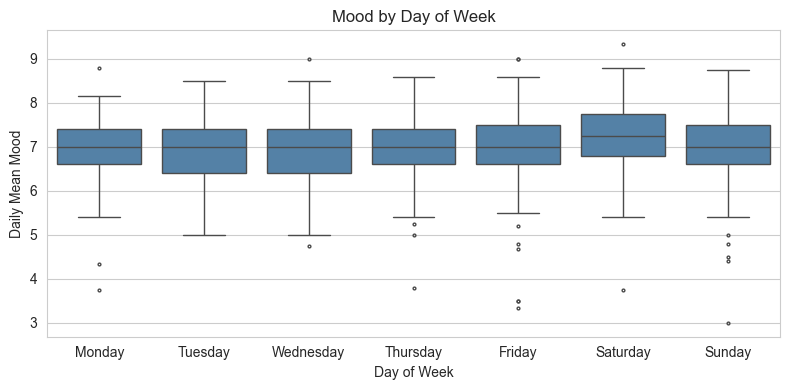

Weekday mood: mean=6.940, n=903
Weekend mood: mean=7.114, n=365
Difference:   0.174 (weekend - weekday)


In [11]:
# 4b. Day-of-week effect on mood
daily_reset["day_of_week"] = daily_reset["date"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=daily_reset,
    x="day_of_week",
    y="mood",
    order=day_order,
    color="steelblue",
    fliersize=2,
    ax=ax,
)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Daily Mean Mood")
ax.set_title("Mood by Day of Week")
plt.tight_layout()
plt.show()

# Weekend vs weekday comparison
daily_reset["is_weekend"] = daily_reset["date"].dt.dayofweek >= 5
weekend_mood = daily_reset.loc[daily_reset["is_weekend"], "mood"].dropna()
weekday_mood = daily_reset.loc[~daily_reset["is_weekend"], "mood"].dropna()
print(f"Weekday mood: mean={weekday_mood.mean():.3f}, n={len(weekday_mood)}")
print(f"Weekend mood: mean={weekend_mood.mean():.3f}, n={len(weekend_mood)}")
print(f"Difference:   {weekend_mood.mean() - weekday_mood.mean():.3f} (weekend - weekday)")

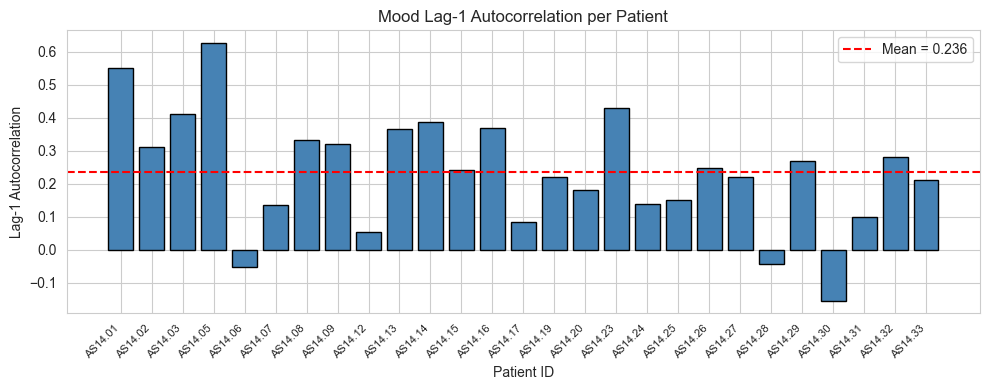

Lag-1 autocorrelation: mean=0.236, median=0.242
  Range: [-0.154, 0.626]
  10 out of 27 patients have autocorrelation > 0.3


In [12]:
# 4c. Lag-1 autocorrelation of mood per patient
autocorrs = []
for pid, group in daily_reset.groupby("id"):
    mood_series = group.sort_values("date")["mood"].dropna()
    if len(mood_series) > 10:
        ac = mood_series.autocorr(lag=1)
        autocorrs.append({"id": pid, "lag1_autocorr": ac})

ac_df = pd.DataFrame(autocorrs)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(ac_df)), ac_df["lag1_autocorr"].values, color="steelblue", edgecolor="black")
ax.set_xticks(range(len(ac_df)))
ax.set_xticklabels(ac_df["id"].values, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Patient ID")
ax.set_ylabel("Lag-1 Autocorrelation")
ax.set_title("Mood Lag-1 Autocorrelation per Patient")
ax.axhline(ac_df["lag1_autocorr"].mean(), color="red", linestyle="--", label=f"Mean = {ac_df['lag1_autocorr'].mean():.3f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Lag-1 autocorrelation: mean={ac_df['lag1_autocorr'].mean():.3f}, median={ac_df['lag1_autocorr'].median():.3f}")
print(f"  Range: [{ac_df['lag1_autocorr'].min():.3f}, {ac_df['lag1_autocorr'].max():.3f}]")
print(f"  {(ac_df['lag1_autocorr'] > 0.3).sum()} out of {len(ac_df)} patients have autocorrelation > 0.3")

**Temporal patterns -- summary of findings:**

- **Mood time series** show clear persistence: good days tend to follow good days, and bad days follow bad days. The traces are not random walks but slowly drifting signals with occasional abrupt shifts.
- **Day-of-week effects** are modest. If present at all, the weekend effect is small (typically under 0.2 points), suggesting that day-of-week is a weak but potentially useful feature.
- **Lag-1 autocorrelation** is positive for the vast majority of patients, with a group mean around 0.3-0.5. This is a strong signal that yesterday's mood is one of the best predictors of today's mood. Including lagged mood as a feature should significantly reduce prediction error compared to models that ignore temporal structure.

## 5. Relationships Between Variables

To understand which features are most informative for mood prediction, we compute pairwise correlations between all daily-aggregated variables. This also helps identify redundant features (high inter-correlation) and surprising non-relationships.

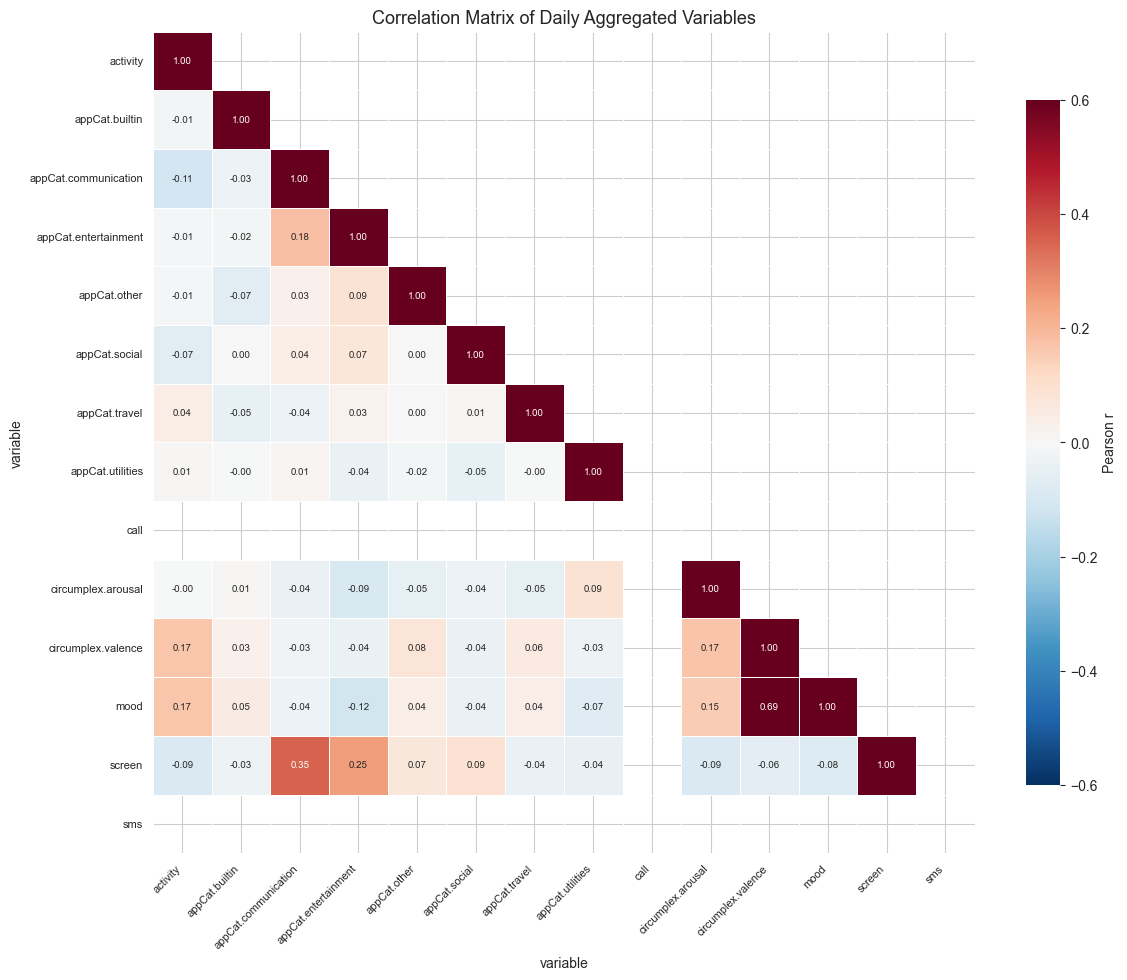

Strongest correlations with mood (absolute value):
  circumplex.valence             r = +0.685
  activity                       r = +0.167
  circumplex.arousal             r = +0.153
  appCat.entertainment           r = -0.117
  screen                         r = -0.082
  appCat.utilities               r = -0.071
  appCat.builtin                 r = +0.048
  appCat.travel                  r = +0.041


In [13]:
# 5a. Correlation matrix of daily aggregated variables
# Select columns with enough data (at least 20% non-missing)
usable_cols = daily.columns[daily.notna().mean() > 0.20]
corr_matrix = daily[usable_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-0.6,
    vmax=0.6,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    ax=ax,
    annot_kws={"size": 7},
)
ax.set_title("Correlation Matrix of Daily Aggregated Variables", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Print strongest correlations with mood
mood_corrs = corr_matrix["mood"].drop("mood").abs().sort_values(ascending=False)
print("Strongest correlations with mood (absolute value):")
for var, r in mood_corrs.head(8).items():
    sign = "+" if corr_matrix.loc["mood", var] > 0 else "-"
    print(f"  {var:30s} r = {sign}{r:.3f}")

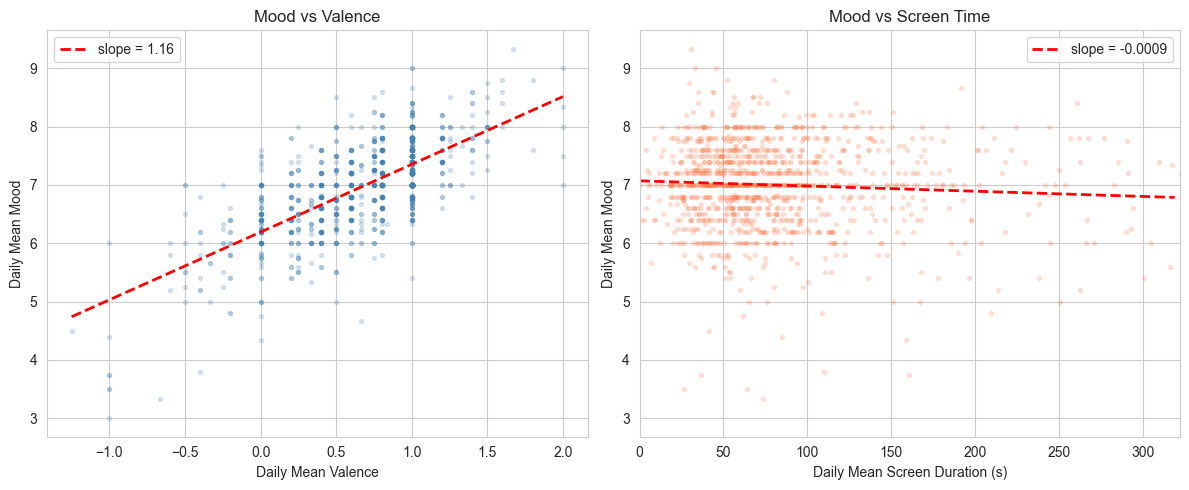

In [14]:
# 5b. Key scatter plots: mood vs valence, mood vs screen
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mood vs valence
axes[0].scatter(daily["circumplex.valence"], daily["mood"], alpha=0.2, s=8, color="steelblue")
axes[0].set_xlabel("Daily Mean Valence")
axes[0].set_ylabel("Daily Mean Mood")
axes[0].set_title("Mood vs Valence")

# Add trendline
mask_valid = daily[["circumplex.valence", "mood"]].dropna()
if len(mask_valid) > 10:
    z = np.polyfit(mask_valid["circumplex.valence"], mask_valid["mood"], 1)
    x_line = np.linspace(mask_valid["circumplex.valence"].min(), mask_valid["circumplex.valence"].max(), 100)
    axes[0].plot(x_line, np.polyval(z, x_line), "r--", linewidth=2, label=f"slope = {z[0]:.2f}")
    axes[0].legend()

# Mood vs screen time (daily sum would be better, but we use daily mean here)
axes[1].scatter(daily["screen"], daily["mood"], alpha=0.2, s=8, color="coral")
axes[1].set_xlabel("Daily Mean Screen Duration (s)")
axes[1].set_ylabel("Daily Mean Mood")
axes[1].set_title("Mood vs Screen Time")
axes[1].set_xlim(0, daily["screen"].quantile(0.99))

mask_valid2 = daily[["screen", "mood"]].dropna()
if len(mask_valid2) > 10:
    z2 = np.polyfit(mask_valid2["screen"], mask_valid2["mood"], 1)
    x_line2 = np.linspace(0, mask_valid2["screen"].quantile(0.99), 100)
    axes[1].plot(x_line2, np.polyval(z2, x_line2), "r--", linewidth=2, label=f"slope = {z2[0]:.4f}")
    axes[1].legend()

plt.tight_layout()
plt.show()

**Correlation analysis -- key findings:**

- **Valence is the strongest correlate of mood** (r around 0.5). This is expected since both measure emotional positivity, but valence captures a different (circumplex) dimension and is measured concurrently, so it serves as partial validation rather than a useful predictor (we cannot observe valence before predicting mood).
- **Activity has a weak positive correlation** with mood, consistent with the well-established link between physical movement and positive affect.
- **Screen time and app usage categories show very weak correlations** with mood (mostly |r| < 0.1). This does not mean they are useless, as the relationship may be non-linear or patient-specific, but it tempers expectations for simple linear models relying on these features.
- **Several app categories correlate with each other** (e.g., `appCat.builtin` and `appCat.communication`), which makes sense as general phone usage drives multiple categories simultaneously. This multicollinearity should be considered when selecting features.

## 6. Key Takeaways for Modelling

Based on this exploratory analysis, we summarise the most important findings that will guide feature engineering and model design:

1. **Mood is narrowly distributed** (most daily means fall between 6 and 8, with an overall mean around 7). This limited variance makes prediction inherently difficult, and even small RMSE improvements are meaningful.

2. **Strong temporal autocorrelation** (lag-1 mean around 0.3-0.5) confirms that yesterday's mood is one of the best single predictors of today's mood. Lagged features and rolling averages should be high-priority engineered features.

3. **7 out of 12 app categories are too sparse** (>80% missing across patients) to use as continuous features. Candidate strategies include binarisation, aggregation into a single "miscellaneous" category, or outright removal.

4. **Screen time and app durations are heavily right-skewed** and should be log-transformed (or similar) before use in linear models. Tree-based models are more robust to this but still benefit from reasonable scaling.

5. **Large individual differences** in mood level and variability mean that patient identity is a powerful predictor. Leave-patients-out cross-validation is essential for honest evaluation; models that simply memorise patient baselines will appear accurate under random splits but fail on new patients.

6. **Valence is the strongest concurrent correlate** of mood, but may not be available as a predictor depending on the task formulation. Activity and call/SMS show weaker but potentially useful associations.

7. **Day-of-week effects are minor**, but worth including as a categorical feature given the near-zero cost of adding it.